In [ ]:
# Cài đặt thư viện EasyOCR và các công cụ hỗ trợ
!pip install easyocr
!pip install opencv-python-headless

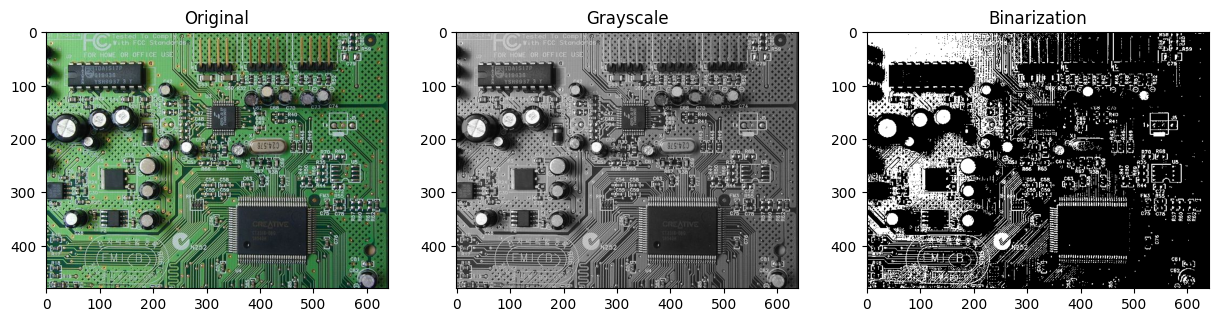

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Load image
image_path = 'sample_license_plate.png'
img = cv2.imread(image_path)

if img is None:
    print(f"Error: Could not load image at {image_path}.")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3. Binarization
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

    # Display results
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.title("Original"); plt.imshow(img_rgb)
    plt.subplot(1, 3, 2); plt.title("Grayscale"); plt.imshow(gray, cmap='gray')
    plt.subplot(1, 3, 3); plt.title("Binarization"); plt.imshow(thresh, cmap='gray')
    plt.show()

In [ ]:
# Download a reliable sample image for demonstration
!wget "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/board.jpg" -O sample_license_plate.png

--2026-04-01 08:32:54--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/board.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 121597 (119K) [image/jpeg]
Saving to: ‘sample_license_plate.png’

sample_license_plat 100%[===================>] 118.75K  --.-KB/s    in 0.01s   

2026-04-01 08:32:54 (10.7 MB/s) - ‘sample_license_plate.png’ saved [121597/121597]



Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteNhận diện được: 'ICC' (Độ tin cậy: 0.31)
Nhận diện được: 'Tested CC' (Độ tin cậy: 0.66)
Nhận diện được: 'Stonc' (Độ tin cậy: 0.58)
Nhận diện được: 'Cowp)' (Độ tin cậy: 0.10)
Nhận diện được: 'For Houe' (Độ tin cậy: 0.43)
Nhận diện được: 'OR Office Usq' (Độ tin cậy: 0.11)
Nhận diện được: 'da1s1ze' (Độ tin cậy: 0.14)
Nhận diện được: '619038' (Độ tin cậy: 0.63)
Nhận diện được: 'Sgoe' (Độ tin cậy: 0.03)
Nhận diện được: 'Ro' (Độ tin cậy: 0.80)
Nhận diện được: '925*+79' (Độ tin cậy: 0.17)
Nhận diện được: '578J86%' (Độ tin cậy: 0.02)
Nhận diện được: 'C73' (Độ tin cậy: 0.44)
Nhận diện được: 'sV ia' (Độ tin cậy: 0.01)


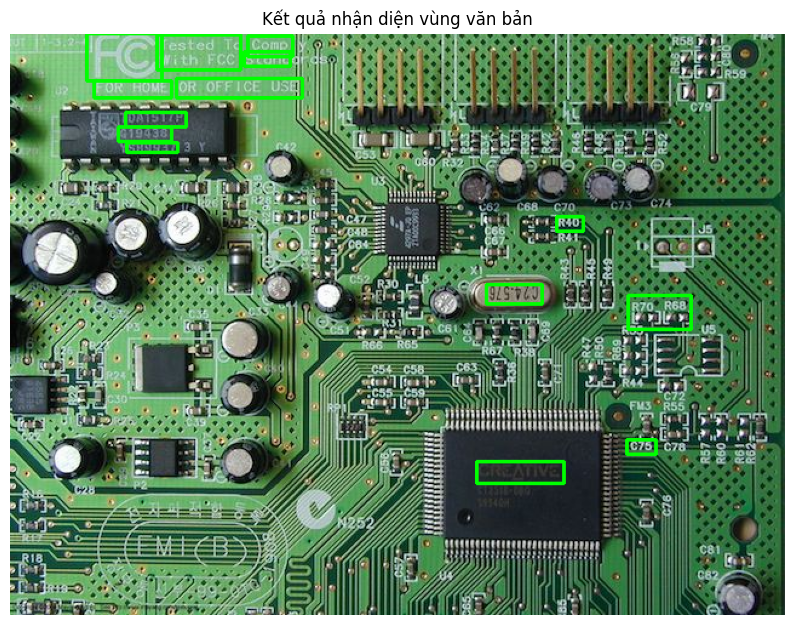

In [ ]:
import easyocr

# Khởi tạo reader với ngôn ngữ Tiếng Việt và Tiếng Anh
reader = easyocr.Reader(['vi', 'en'])

# Chạy nhận diện trên ảnh
results = reader.readtext(image_path)

# Vẽ khung bao (Bounding Box) quanh các vùng phát hiện được
output_img = img_rgb.copy()
for (bbox, text, prob) in results:
    # Lấy tọa độ khung
    (top_left, top_right, bottom_right, bottom_left) = bbox
    top_left = tuple(map(int, top_left))
    bottom_right = tuple(map(int, bottom_right))

    # Vẽ hình chữ nhật và ghi chú chữ nhận diện được
    cv2.rectangle(output_img, top_left, bottom_right, (0, 255, 0), 2)
    print(f"Nhận diện được: '{text}' (Độ tin cậy: {prob:.2f})")

plt.figure(figsize=(10, 10))
plt.imshow(output_img)
plt.title("Kết quả nhận diện vùng văn bản")
plt.axis('off')
plt.show()

In [ ]:
# Gom tất cả các đoạn text lại thành một văn bản hoàn chỉnh
full_text = "\n".join([res[1] for res in results])

print("-" * 30)
print("VĂN BẢN TRÍCH XUẤT ĐƯỢC:")
print("-" * 30)
print(full_text)

------------------------------
VĂN BẢN TRÍCH XUẤT ĐƯỢC:
------------------------------
ICC
Tested CC
Stonc
Cowp)
For Houe
OR Office Usq
da1s1ze
619038
Sgoe
Ro
925*+79
578J86%
C73
sV ia


In [ ]:
!apt-get install tesseract-ocr tesseract-ocr-vie -y
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-vie
0 upgraded, 1 newly installed, 0 to remove and 42 not upgraded.
Need to get 417 kB of archives.
After this operation, 546 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-vie all 1:4.00~git30-7274cfa-1.1 [417 kB]
Fetched 417 kB in 1s (423 kB/s)
Selecting previously unselected package tesseract-ocr-vie.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-vie_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-vie (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-vie (1:4.00~git30-7274cfa-1.1) ...


Tìm thấy 14 vùng chứa thông tin.

--- ẢNH KẾT QUẢ VỚI CÁC BBOX ---


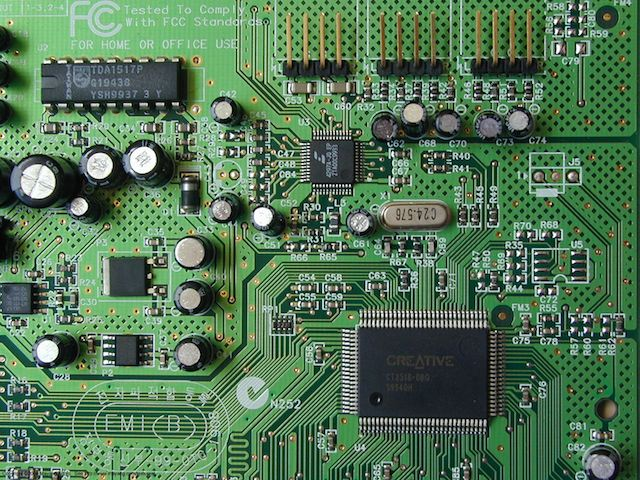

In [ ]:
import cv2
import pytesseract
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# 1. ĐỌC ẢNH VÀ TIỀN XỬ LÝ
# Thay đổi từ 'example.png' sang 'sample_license_plate.png' đã có sẵn
image_path = 'sample_license_plate.png'
img = cv2.imread(image_path)

if img is None:
    print(f"Không tìm thấy file: {image_path}")
else:
    h, w, _ = img.shape
    # Chuyển ảnh xám để xử lý ma trận điểm ảnh
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. XÁC ĐỊNH VÙNG VĂN BẢN & LẤY BBOX (Bounding Box)
    data = pytesseract.image_to_data(gray, lang='vie', output_type=pytesseract.Output.DICT)

    print(f"Tìm thấy {len(data['text'])} vùng chứa thông tin.")

    # Tạo bản sao để vẽ kết quả
    img_canvas = img.copy()

    # Duyệt qua từng vùng đã xác định
    for i in range(len(data['text'])):
        # Chỉ xử lý nếu độ tin cậy (conf) > 60 và text không rỗng
        if int(float(data['conf'][i])) > 60 and data['text'][i].strip():
            x, y, word_w, word_h = data['left'][i], data['top'][i], data['width'][i], data['height'][i]

            # Cắt vùng ảnh nhỏ chứa từ đó ra khỏi ảnh gốc
            word_crop = gray[y:y+word_h, x:x+word_w]

            # Nhận diện chữ trong vùng đã cắt
            recognized_text = pytesseract.image_to_string(word_crop, lang='vie', config='--psm 7').strip()

            # Vẽ khung lên ảnh
            cv2.rectangle(img_canvas, (x, y), (x + word_w, y + word_h), (0, 255, 0), 2)
            print(f"Vùng [{x},{y}]: Trích xuất được từ -> '{recognized_text}'")

    # Hiển thị kết quả cuối cùng
    print("\n--- ẢNH KẾT QUẢ VỚI CÁC BBOX ---")
    cv2_imshow(img_canvas)

📦 Đang tải MNIST (chữ số)...


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.39MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.4MB/s]


📦 Đang tải EMNIST (chữ cái)...


100%|██████████| 562M/562M [00:01<00:00, 292MB/s]


🔍 Đang lập chỉ mục...
✅ Sẵn sàng!



/tmp/ipykernel_5100/893439128.py:196: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=1.5)
/tmp/ipykernel_5100/893439128.py:197: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.savefig('license_plates.png', dpi=150, bbox_inches='tight',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


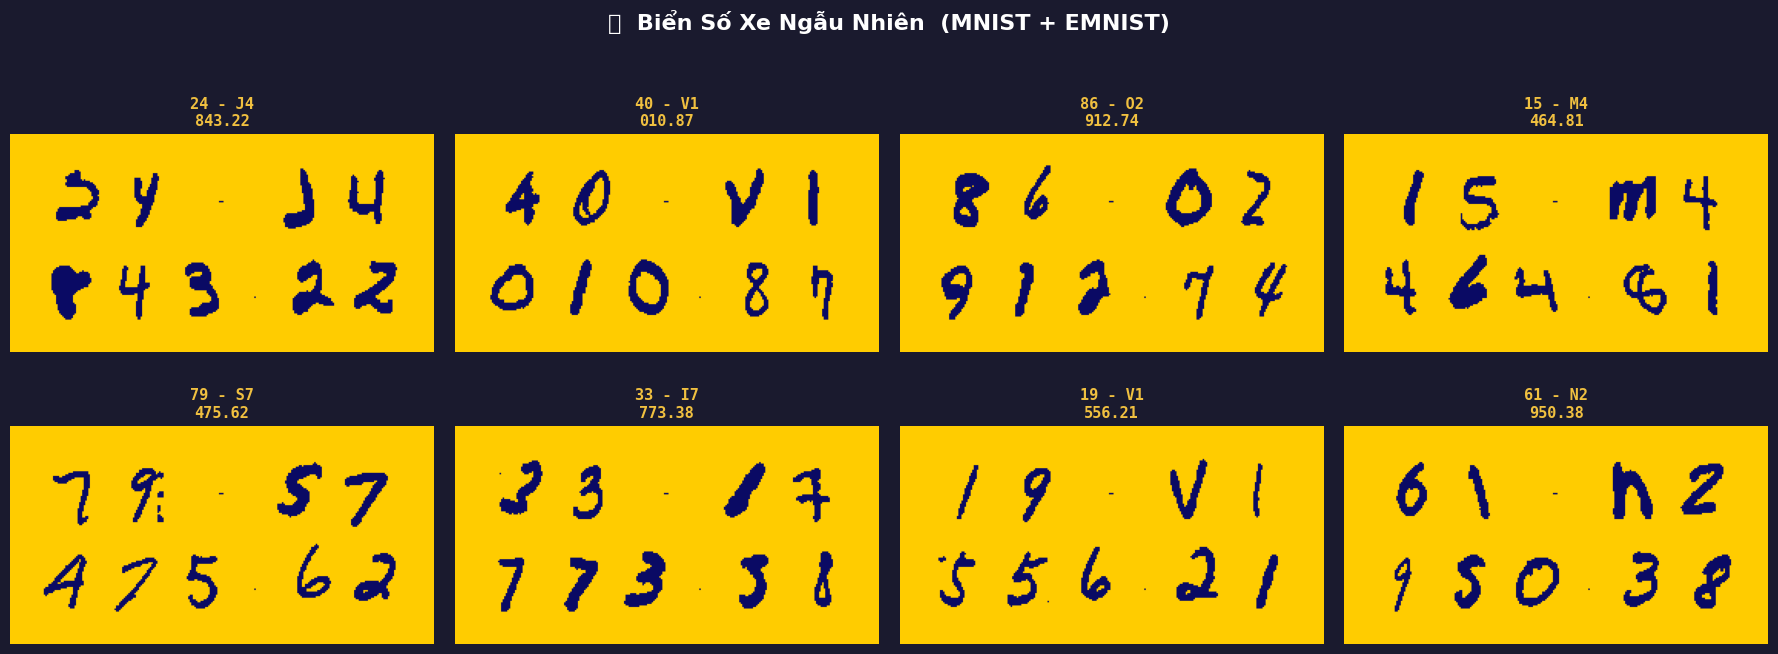

💾 Đã lưu → license_plates.png


In [ ]:
import random
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────
#  1. TẢI DỮ LIỆU
# ─────────────────────────────────────────────
transform = transforms.ToTensor()

print("📦 Đang tải MNIST (chữ số)...")
mnist = datasets.MNIST('./data', train=True, download=True, transform=transform)

print("📦 Đang tải EMNIST (chữ cái)...")
emnist = datasets.EMNIST('./data', split='letters', train=True, download=True, transform=transform)

# ─────────────────────────────────────────────
#  2. LẬP CHỈ MỤC THEO NHÃN
# ─────────────────────────────────────────────
def index_dataset(dataset):
    index = {}
    for img, label in dataset:
        label = int(label)
        arr = img.squeeze().numpy()
        index.setdefault(label, []).append(arr)
    return index

print("🔍 Đang lập chỉ mục...")
mnist_idx  = index_dataset(mnist)   # key: 0–9
emnist_idx = index_dataset(emnist)  # key: 1–26 (A=1, B=2, ...)
print("✅ Sẵn sàng!\n")

# ─────────────────────────────────────────────
#  3. HẰNG SỐ & TẬP KÝ TỰ
# ─────────────────────────────────────────────
LETTERS  = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
CHAR_H   = 48          # chiều cao ký tự (px)
CHAR_W   = 38          # chiều rộng ký tự (px)
GAP      = 6           # khoảng cách giữa ký tự (px)
LINE_GAP = 10          # khoảng cách giữa 2 dòng (px)
MARGIN   = 18          # viền biển số (px)

# Màu biển số Việt Nam
BG_COLOR   = (255, 204,  0)   # nền vàng
TEXT_COLOR = ( 10,  10, 100)  # chữ xanh đậm
PLATE_BORDER = (180, 140, 0)  # viền

# ─────────────────────────────────────────────
#  4. LẤY ẢNH KÝ TỰ
# ─────────────────────────────────────────────
def get_digit_img(d: int) -> np.ndarray:
    """Lấy ngẫu nhiên ảnh chữ số từ MNIST, resize về CHAR_H×CHAR_W."""
    arr = random.choice(mnist_idx[d])
    pil = Image.fromarray((arr * 255).astype(np.uint8))
    pil = pil.resize((CHAR_W, CHAR_H), Image.LANCZOS)
    return np.array(pil, dtype=np.uint8)

def get_letter_img(c: str) -> np.ndarray:
    """Lấy ngẫu nhiên ảnh chữ cái từ EMNIST, sửa hướng & resize."""
    label = LETTERS.index(c.upper()) + 1   # EMNIST letters: A=1, Z=26
    arr = random.choice(emnist_idx[label])
    # EMNIST lưu ảnh bị xoay so với MNIST → cần chỉnh lại
    arr = np.transpose(arr)
    pil = Image.fromarray((arr * 255).astype(np.uint8))
    pil = pil.resize((CHAR_W, CHAR_H), Image.LANCZOS)
    return np.array(pil, dtype=np.uint8)

# ─────────────────────────────────────────────
#  5. DỰNG ẢNH TỪNG DÒNG
# ─────────────────────────────────────────────
def make_separator(text: str, height: int, width: int) -> np.ndarray:
    """Tạo ảnh xám cho ký tự phân cách (' - ' hoặc '.')."""
    img = Image.new('L', (width, height), 0)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 28)
    except:
        font = ImageFont.load_default()
    bbox = draw.textbbox((0, 0), text, font=font)
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    draw.text(((width - tw) // 2, (height - th) // 2 - 2), text, fill=220, font=font)
    return np.array(img, dtype=np.uint8)

def concat_horizontal(char_imgs: list, gap: int = GAP) -> np.ndarray:
    """Ghép ngang danh sách ảnh grayscale với khoảng cách gap."""
    total_w = sum(img.shape[1] for img in char_imgs) + gap * (len(char_imgs) - 1)
    canvas = np.zeros((CHAR_H, total_w), dtype=np.uint8)
    x = 0
    for img in char_imgs:
        h, w = img.shape
        y_off = (CHAR_H - h) // 2
        canvas[y_off:y_off + h, x:x + w] = img
        x += w + gap
    return canvas

# ─────────────────────────────────────────────
#  6. SINH BIỂN SỐ
# ─────────────────────────────────────────────
def generate_plate():
    """
    Sinh biển số ngẫu nhiên dạng:
        Dòng 1:  XX - YX
        Dòng 2:  XXX.XX
    X = chữ số (MNIST), Y = chữ cái (EMNIST)
    """
    # Sinh ngẫu nhiên các thành phần
    d1 = random.randint(1, 9)                  # tỉnh/thành (không bắt đầu bằng 0)
    d2 = random.randint(0, 9)
    letter = random.choice(LETTERS)
    d3 = random.randint(1, 9)
    d4 = random.randint(0, 9)
    d5 = random.randint(0, 9)
    d6 = random.randint(0, 9)
    d7 = random.randint(0, 9)
    d8 = random.randint(0, 9)

    text1 = f"{d1}{d2} - {letter}{d3}"
    text2 = f"{d4}{d5}{d6}.{d7}{d8}"

    # ── Dòng 1: XX - YX ──
    sep_dash = make_separator(" - ", CHAR_H, CHAR_W + GAP * 2)
    line1_imgs = [
        get_digit_img(d1),
        get_digit_img(d2),
        sep_dash,
        get_letter_img(letter),
        get_digit_img(d3),
    ]
    line1 = concat_horizontal(line1_imgs)

    # ── Dòng 2: XXX.XX ──
    sep_dot = make_separator(".", CHAR_H, 20)
    line2_imgs = [
        get_digit_img(d4),
        get_digit_img(d5),
        get_digit_img(d6),
        sep_dot,
        get_digit_img(d7),
        get_digit_img(d8),
    ]
    line2 = concat_horizontal(line2_imgs)

    # Căn chỉnh chiều rộng hai dòng bằng nhau
    max_w = max(line1.shape[1], line2.shape[1])

    def center_pad(img, target_w):
        pad = target_w - img.shape[1]
        lp, rp = pad // 2, pad - pad // 2
        return np.pad(img, ((0, 0), (lp, rp)))

    line1 = center_pad(line1, max_w)
    line2 = center_pad(line2, max_w)

    # Ghép dọc hai dòng
    divider = np.zeros((LINE_GAP, max_w), dtype=np.uint8)
    plate_gray = np.vstack([line1, divider, line2])

    # ── Tô màu biển số ──
    ph, pw = plate_gray.shape
    plate_rgb = np.ones((ph + 2 * MARGIN, pw + 2 * MARGIN, 3), dtype=np.uint8)
    plate_rgb[:, :] = BG_COLOR

    # Đặt ký tự màu xanh đậm lên nền vàng
    mask = plate_gray > 50
    content_region = plate_rgb[MARGIN:MARGIN + ph, MARGIN:MARGIN + pw]
    content_region[mask] = TEXT_COLOR
    plate_rgb[MARGIN:MARGIN + ph, MARGIN:MARGIN + pw] = content_region

    return plate_rgb, text1, text2

# ─────────────────────────────────────────────
#  7. HIỂN THỊ KẾT QUẢ
# ─────────────────────────────────────────────
N_PLATES = 8
fig, axes = plt.subplots(2, N_PLATES // 2, figsize=(18, 7))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('🚗  Biển Số Xe Ngẫu Nhiên  (MNIST + EMNIST)',
             fontsize=16, color='white', fontweight='bold', y=1.01)

for ax in axes.flat:
    plate_img, t1, t2 = generate_plate()

    ax.imshow(plate_img)
    ax.set_title(f"{t1}\n{t2}",
                 fontsize=11, color='#f0c040',
                 fontfamily='monospace', fontweight='bold')
    ax.axis('off')

    # Vẽ viền biển số
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout(pad=1.5)
plt.savefig('license_plates.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print("💾 Đã lưu → license_plates.png")

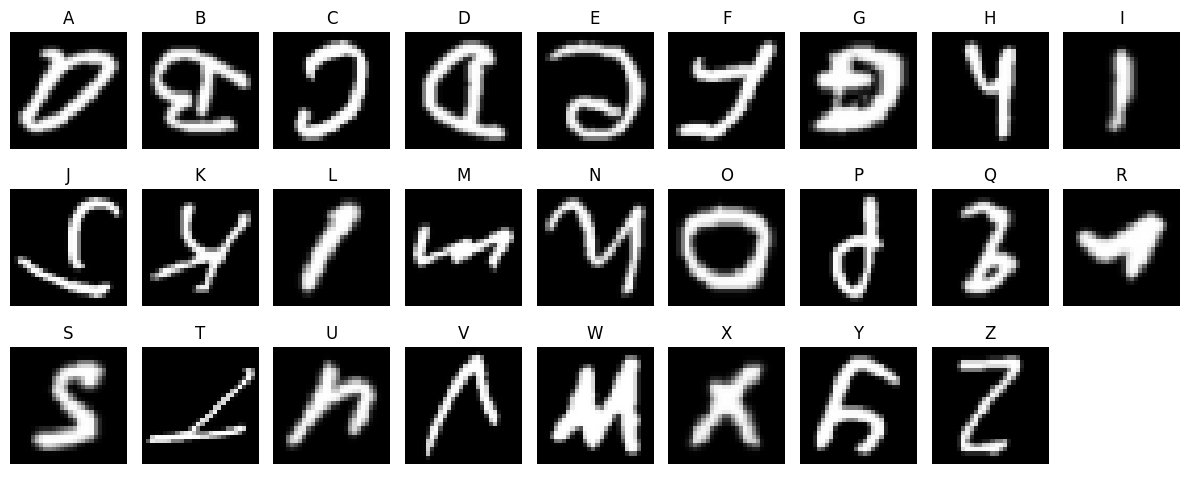

In [ ]:
from torchvision.datasets import EMNIST
from torchvision import transforms
import matplotlib.pyplot as plt

# Transform
transform = transforms.ToTensor()

# Load dataset
dataset = EMNIST(root='./data', split='letters', train=True, download=True, transform=transform)

# Dictionary lưu 1 sample cho mỗi label
samples = {}

# Lấy đủ 26 ký tự (1–26)
for img, label in dataset:
    if label not in samples:
        samples[label] = img
    if len(samples) == 26:
        break

# Tạo grid 3x9 (27 ô, dư 1 ô)
fig, axes = plt.subplots(3, 9, figsize=(12, 5))

axes = axes.flatten()

for i in range(27):
    ax = axes[i]

    if i < 26:
        label = i + 1  # EMNIST letters: 1–26
        img = samples[label]

        # Fix xoay ảnh EMNIST
        img = img.squeeze().numpy()
        img = np.rot90(img, k=1)
        img = np.fliplr(img)

        # Convert label → ký tự
        char = chr(label + 96)  # 1->a, 2->b,...

        ax.imshow(img, cmap='gray')
        ax.set_title(char.upper())
    else:
        ax.axis('off')  # ô dư

    ax.axis('off')

plt.tight_layout()
plt.show()

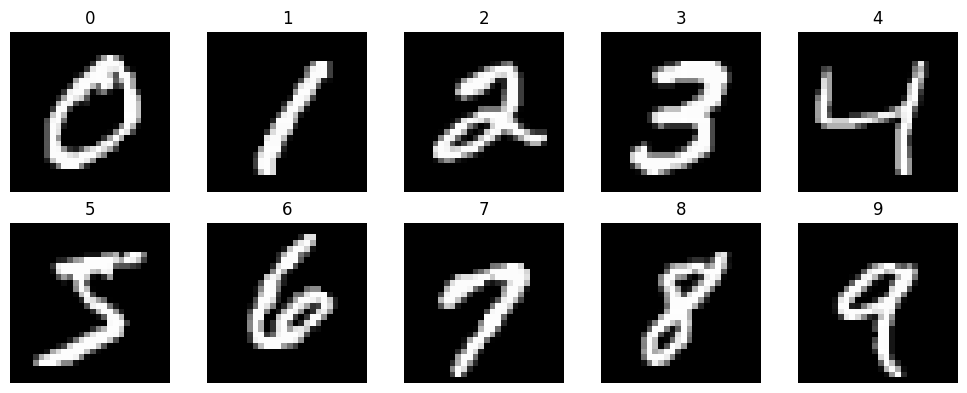

In [ ]:
from torchvision.datasets import MNIST
from torchvision import transforms
import matplotlib.pyplot as plt

# Transform
transform = transforms.ToTensor()

# Load dataset
dataset = MNIST(root='./data', train=True, download=True, transform=transform)

# Lưu 1 sample cho mỗi label (0–9)
samples = {}

for img, label in dataset:
    if label not in samples:
        samples[label] = img
    if len(samples) == 10:
        break

# Tạo grid 2x5
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

for i in range(10):
    img = samples[i]

    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f"{i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# scikit-learn
#torch, torchvision
from sklearn import svm
from skimage.feature import hog
from torchvision.datasets import MNIST
from torchvision import transforms

# Load MNIST
dataset = MNIST(root='./data', train=True, download=True)
#X là tập dữ liệu, y là nhãn: X là hình thứ nhất, y = 6  ,
X, y = [], []

for img, label in dataset:
    img = img.resize((28,28)) # vì sao phải resize image?
    feature = hog(img, pixels_per_cell=(4,4)) # tra xem HOG là làm gì?
    X.append(feature)
    y.append(label)

clf = svm.SVC()
clf.fit(X[:5000], y[:5000])

SVC()

In [ ]:
from tqdm import tqdm

count = 0

for i in tqdm(range(5001, 10000)):
    pred = clf.predict([X[i]])
    if pred != y[i]:
        count += 1

print("\n",count/5000.0)

100%|██████████| 4999/4999 [00:31<00:00, 161.14it/s]


 0.0254


In [ ]:
print("\n",count/4999.0)


 0.02540508101620324


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from torchvision.datasets import MNIST
import numpy as np

# Load data
dataset = MNIST(root='./data', train=True, download=True)

X, y = [], []

# Lấy 2000 sample cho nhanh (KNN rất chậm)
for i in range(15000):
    img, label = dataset[i]
    X.append(np.array(img).flatten())
    y.append(label)

X = np.array(X)
y = np.array(y)

# Train KNN
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X[:10000], y[:10000])

# Predict thử
pred = model.predict([X[0]])
print("Predict:", pred, "True:", y[0])

Predict: [5] True: 5


In [ ]:
count = 0

for i in tqdm(range(10001, 15000)):
    pred = model.predict([X[i]])
    if pred != y[i]:
        count += 1


100%|██████████| 4999/4999 [02:36<00:00, 32.04it/s]


In [ ]:
print("\n",count/4999.0)


 0.05521104220844169


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader

# Load data
transform = transforms.ToTensor()
train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Model CNN
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),  # 3x3
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3), # 3x3
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# Init model
model = CNN()

# Loss + optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
for epoch in range(3):
    total_loss = 0

    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 172.0993
Epoch 2, Loss: 51.6648
Epoch 3, Loss: 35.1097


In [ ]:
for images, labels in train_loader:
  print(images.shape)
  break


torch.Size([64, 1, 28, 28])


In [ ]:
from tqdm import tqdm
import torch

model.eval()  # chuyển sang chế độ evaluation

count = 0

with torch.no_grad():
    for i in tqdm(range(10001, 15000)):
        img = X[i] # img is a numpy.ndarray of shape (784,)

        # Reshape to (28, 28), convert to torch tensor, normalize to [0, 1],
        # then add channel (1) and batch (1) dimensions.
        img = torch.from_numpy(img.reshape(28, 28)).float().unsqueeze(0).unsqueeze(0) / 255.0
        output = model(img)
        pred = torch.argmax(output, dim=1).item() # nguyên tắc

        if pred != y[i]:
            count += 1

print("Errors:", count)

100%|██████████| 4999/4999 [00:03<00:00, 1632.88it/s]

Errors: 35


In [ ]:
print(count/4999.0)

0.007001400280056011
